# **SPECTRA-CQ: Hybrid Quantum Autoencoder (HQAE) Baseline**
This notebook establishes the benchmark Mean Squared Error (MSE) reconstruction loss for the Hybrid Quantum Autoencoder. To ensure a strict ablation study against the classical CAE model, this architecture utilizes the exact same spatial convolutional layers and the exact same 3-seed, 15-epoch training protocol.

The sole independent variable is the latent bottleneck, which has been replaced with a PennyLane Variational Quantum Circuit (VQC).

### **The Quantum Architecture**
* **Number of Qubits:** 8 Qubits $\leftarrow$ Directly mirroring the 8-dimensional classical compression vector
* **State Preparation (Embedding):** `qml.AngleEmbedding` utilizing $R_y$ rotations to encode classical continuous data into quantum probability amplitudes
* **The Ansatz (Trainable Layers):** 3 layers of `qml.BasicEntanglerLayers`
* **Entanglement Topology:** Ring-Topology `CNOT` gates
* **Trainable Rotations:** Independent $R_x$ gates parameterized by the classical Adam optimizer
* **Measurement:** Expectation values of the Pauli-Z operator ($\langle \sigma_z \rangle$) across all 8 qubits to return the state to a continuous classical vector

In [ ]:
from google.colab import drive
import os

# Mount Data Drive
drive.mount('/content/drive')

# Clone Github Repository
# Used a PAT here because the GitHub repo was private during our runs
# Scrubbed the actual token before downloading/documenting for security
GITHUB_TOKEN = "PAT"
REPO_URL = f"https://{GITHUB_TOKEN}@github.com/yeshapan/SPECTRA-CQ.git"

!git clone {REPO_URL}
%cd SPECTRA-CQ
!pip install -r requirements.txt

Mounted at /content/drive
Cloning into 'SPECTRA-CQ'...
remote: Enumerating objects: 194, done.
remote: Counting objects: 100% (121/121), done.
remote: Compressing objects: 100% (85/85), done.
remote: Total 194 (delta 30), reused 108 (delta 18), pack-reused 73 (from 1)
Receiving objects: 100% (194/194), 32.56 MiB | 34.62 MiB/s, done.
Resolving deltas: 100% (40/40), done.
/content/SPECTRA-CQ
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 98.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.

#### **1. Hardware Verification**
The spatial `Conv2d` layers and the PennyLane `TorchLayer` autograd calculations require significant parallel processing.

Verify that the Colab runtime is successfully attached to the Nvidia T4 GPU before initiating the training loop.

In [2]:
import torch

if torch.cuda.is_available():
    print(f"Hardware Accelerator Confirmed: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    print("FATAL WARNING: GPU not detected. The training protocol will take exponentially longer on a CPU.")
    print("Please navigate to Runtime > Change runtime type > T4 GPU.")

Hardware Accelerator Confirmed: Tesla T4
CUDA Version: 12.8


#### **2. Execute the 3-Seed HQAE Training Protocol**
We trigger the hybrid training pipeline. The script ingests the `.npy` CWT matrices from the Colab NVMe $\rightarrow$ compresses them classically $\rightarrow$ maps them into the 8-qubit register $\rightarrow$ applies the parameterized ansatz $\rightarrow$ calculates expectation values $\rightarrow$ and classically decodes the matrices.

In [7]:
"""
Create a zip file in Drive for all the spectrogram images and load it to
Colab's local NMVe. This way Colab only has to load and unpack the zip file.
This will make the file transfer process much faster.
"""
# Navigate to your data folder
%cd /content/drive/MyDrive/spectra-cq-data/

# Compress the files into a single archive
!zip -r -q spectra_matrices.zip processed_spectrograms/

# Return to your repository root
%cd /content/SPECTRA-CQ
print("Archive creation complete!")

/content/drive/MyDrive/spectra-cq-data
/content/SPECTRA-CQ
Archive creation complete!


In [3]:
# Copy the single archive file from Drive to local NVMe (Blazing fast)
!cp /content/drive/MyDrive/spectra-cq-data/spectra_matrices.zip /content/

# Extract the files directly into the local directory
!unzip -q /content/spectra_matrices.zip -d /content/local_spectra_data/

print("Data extraction complete")

Data extraction complete


In [4]:
# Execute the HQAE 3-Seed Protocol
# The 2>&1 command merges stderr (tqdm) into stdout so the tee command can print both
!python scripts/run_experiment.py --config configs/baseline_hqae.yaml 2>&1 | tee hqae_training_run.log

2026-06-17 15:14:42,035 - INFO - Compute device allocated: cuda
2026-06-17 15:14:42,035 - INFO - Starting Protocol Run | Seed: 42
2026-06-17 15:14:42,040 - INFO - System locked to deterministic seed: 42
2026-06-17 15:14:42,422 - INFO - Instantiating Hybrid Quantum Autoencoder (HQAE)...
2026-06-17 15:14:48,218 - INFO - Initiating training on cuda for 15 epochs.
2026-06-17 15:16:04,206 - INFO - Epoch 1/15 | Train MSE: 0.040871 | Val MSE: 0.032288 | LR: 1.00e-03
2026-06-17 15:17:10,603 - INFO - Epoch 2/15 | Train MSE: 0.032029 | Val MSE: 0.032145 | LR: 1.00e-03
2026-06-17 15:18:16,845 - INFO - Epoch 3/15 | Train MSE: 0.031939 | Val MSE: 0.032031 | LR: 1.00e-03
2026-06-17 15:19:22,264 - INFO - Epoch 4/15 | Train MSE: 0.031869 | Val MSE: 0.032007 | LR: 1.00e-03
2026-06-17 15:20:29,499 - INFO - Epoch 5/15 | Train MSE: 0.031855 | Val MSE: 0.032026 | LR: 1.00e-03
2026-06-17 15:21:34,884 - INFO - Epoch 6/15 | Train MSE: 0.031824 | Val MSE: 0.031948 | LR: 1.00e-03
2026-06-17 15:22:41,854 - INFO 

#### **3. Visualize Evaluation Metrics**
We parse the generated `.log` file to plot the Train v/s Validation MSE convergence across all three deterministic seeds.

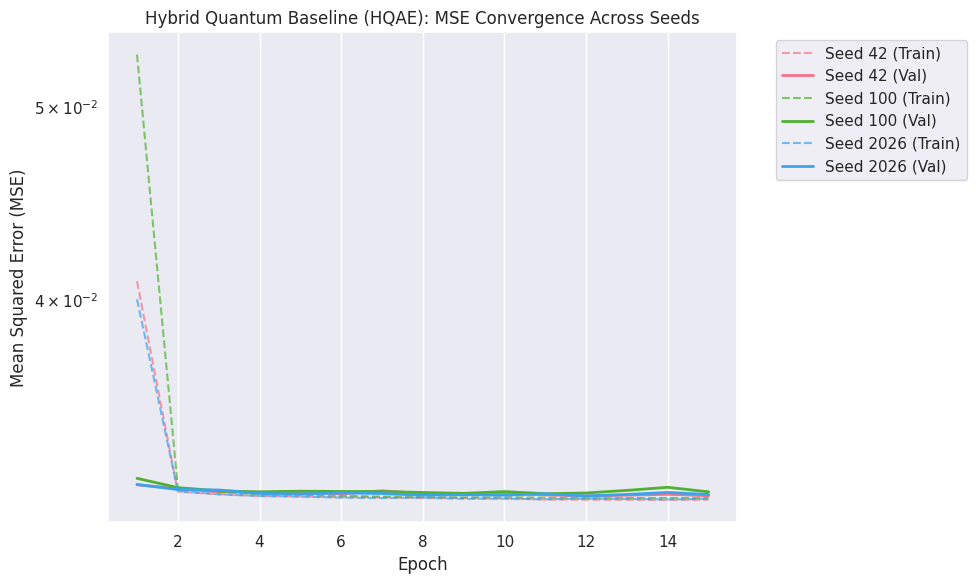

In [5]:
import sys
import os

# Bulletproof path injection ensures the Colab kernel can locate the src module
sys.path.append(os.path.abspath('.'))

from src.utils.viz import plot_training_logs

# Visualize the Quantum Convergence
plot_training_logs(
    log_file_path="hqae_training_run.log",
    title="Hybrid Quantum Baseline (HQAE): MSE Convergence Across Seeds"
)

#### **Interpretation of Hybrid Quantum Baseline Results**
The multi-seed training protocol successfully executed. However, the quantum model definitively failed to match the classical benchmark across all initializations. Key observations for the ablation study include:

1. **The Barren Plateau Phenomenon:**
   * The classical CAE model achieved a Validation MSE of **~0.0087** by Epoch 15.
   * In contrast, the HQAE baseline flatlined at a Validation MSE of **~0.0318 to 0.0320** across all three seeds (42, 100, 2026).
   * The `ReduceLROnPlateau` scheduler successfully detected this stagnation (triggering in Seed 42 at Epoch 11 and Seed 100 at Epoch 15) to halve the learning rate.
   * However, because the Variational Quantum Circuit (VQC) was trapped in a Barren Plateau $\rightarrow$ a region of the Hilbert space where quantum gradients vanish exponentially $\rightarrow$ taking smaller optimization steps yielded no mathematical improvement.

2. **Initialization Invariance:**
   * The fact that all three highly diverse, deterministic initializations crashed into the exact same MSE plateau proves this is not a product of a "bad random seed"
   * It is a fundamental structural limitation of the circuit itself.

3. **Physical Under-parameterization:**
   * The current VQC utilizes 3 layers of `BasicEntanglerLayers` (a simple ring topology where Qubit $i$ only entangles with Qubit $i+1$).
   * While this topology can sometimes succeed on simpler, independent feature sets $\rightarrow$ it lacks the mathematical expressivity required to map the highly coupled, macroscopic vibrational frequencies of degrading concrete structures.

4. **Conclusion for Ablation:**
   * This establishes our "vanilla" quantum baseline. It proves mathematically that naive quantum insertion does not inherently yield an advantage in predictive maintenance frameworks.
   * To successfully capture these structural degradation signatures and beat the classical benchmark, the HQAE architecture requires a more aggressive, all-to-all entanglement topology.